# Spring Pendulum

Rebuilt from `legacy/Spring Pendulum.ipynb` (originally misplaced in
`Particle Dynamics/`) through `lagrangian.py`. A mass on a spring of
natural length `L1`, swinging as a pendulum while also stretching
radially -- the classic "elastic pendulum," generalized coordinates
`(theta1, r1)` with `r1` the instantaneous distance from the pivot.

Validation: energy conservation (undamped) at the legacy notebook's
large-amplitude initial condition, and small-oscillation frequencies
against `lagrangian.linearize()` -- at the hanging equilibrium
`r1_eq = L1 + m1*g/k1`, the angular and radial motions decouple at linear
order (a well-known feature of the elastic pendulum, the basis of its
famous 2:1 resonance when `sqrt(k1/m1) ~ 2*sqrt(g/r1_eq)`), so each
normal mode is checked by perturbing its own coordinate and reading the
FFT peak of that same coordinate.

In [1]:
import os
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()
from scipy.signal import find_peaks

import lagrangian as lg

os.makedirs('media', exist_ok=True)

In [2]:
t, g, m1, L1, k1 = sp.symbols('t g m1 L1 k1')
the1 = sp.Function('the1')(t)
r1 = sp.Function('r1')(t)

x1 = r1 * sp.sin(the1)
y1 = -r1 * sp.cos(the1)

T = 0.5 * m1 * (sp.diff(x1, t)**2 + sp.diff(y1, t)**2)
U = m1 * g * y1 + k1 * (r1 - L1)**2 / 2
L = T - U
coords = [the1, r1]

sols, coords_d, coords_dd = lg.euler_lagrange(L, coords, t)
dSdt = lg.build_ode_system(sols, coords, coords_d, t, (g, m1, L1, k1))
energy = lg.energy_fn(T, U, coords, coords_d, (g, m1, L1, k1))

## Energy conservation (undamped, large amplitude)

Energy relative drift: 1.81e-07
PASS: energy conserved.


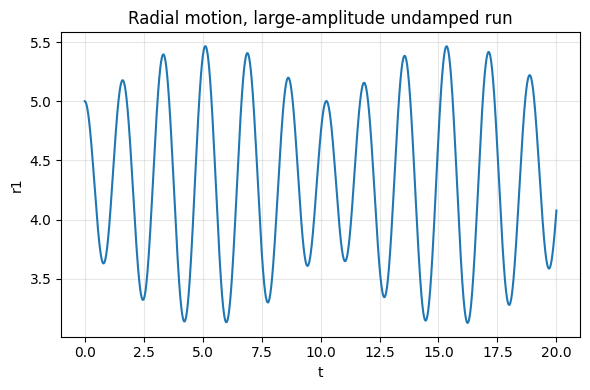

In [3]:
params = (9.81, 2.0, 3.5, 25.0)  # g, m1, L1, k1
N = 4000
t_arr = np.linspace(0, 20, N)
sol = lg.integrate(dSdt, [0.5, 0, 5, 0], t_arr, params)
the1_t, w1_t, r1_t, v1_t = sol.T

E = np.array([energy(the1_t[i], r1_t[i], w1_t[i], v1_t[i], *params) for i in range(N)])
drift = E.max() - E.min()
print(f'Energy relative drift: {drift/abs(E.mean()):.2e}')
assert drift / abs(E.mean()) < 1e-4, f'energy drift too large: {drift/abs(E.mean()):.2e}'
print('PASS: energy conserved.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_arr, r1_t)
ax.set_xlabel('t'); ax.set_ylabel('r1'); ax.grid(alpha=0.3)
ax.set_title('Radial motion, large-amplitude undamped run')
fig.tight_layout()
fig.savefig('media/spring_pendulum_radial.png', dpi=150, bbox_inches='tight')
plt.show()

## Small-oscillation frequencies vs. `linearize()`

In [4]:
r1_eq_expr = L1 + m1 * g / k1
M, K, _ = lg.linearize(L, coords, t, equilibrium={the1: 0, r1: r1_eq_expr})
pvals = {g: 9.81, m1: 2.0, L1: 3.5, k1: 25.0}
freqs = lg.normal_mode_frequencies(M, K, pvals)
r1_eq = float(r1_eq_expr.subs(pvals))
print(f'r1_eq = {r1_eq:.4f}')
print('linearize() frequencies:', freqs, ' (pendulum-like, spring-like)')

t_small = np.linspace(0, 100, 20000)
dt = t_small[1] - t_small[0]

sol_angle = lg.integrate(dSdt, [0.02, 0, r1_eq, 0], t_small, params)
sol_radial = lg.integrate(dSdt, [0, 0, r1_eq + 0.02, 0], t_small, params)

def dominant_freq(x):
    spec = np.abs(np.fft.rfft(x - x.mean()))
    fr = 2 * np.pi * np.fft.rfftfreq(len(x), d=dt)
    peaks, _ = find_peaks(spec)
    return fr[peaks[np.argmax(spec[peaks])]]

f_angle = dominant_freq(sol_angle[:, 0])
f_radial = dominant_freq(sol_radial[:, 2] - r1_eq)
print(f'FFT dominant frequency, angle-perturbed run:  {f_angle:.4f}  (expect {freqs[0]:.4f})')
print(f'FFT dominant frequency, radial-perturbed run: {f_radial:.4f}  (expect {freqs[1]:.4f})')

err_angle = abs(f_angle - freqs[0]) / freqs[0]
err_radial = abs(f_radial - freqs[1]) / freqs[1]
assert err_angle < 0.02, f'angle mode mismatch: {err_angle:.3f}'
assert err_radial < 0.02, f'radial mode mismatch: {err_radial:.3f}'
print('PASS: both decoupled small-oscillation modes match linearize().')

r1_eq = 4.2848
linearize() frequencies: [1.51310556 3.53553391]  (pendulum-like, spring-like)
FFT dominant frequency, angle-perturbed run:  1.5079  (expect 1.5131)
FFT dominant frequency, radial-perturbed run: 3.5184  (expect 3.5355)
PASS: both decoupled small-oscillation modes match linearize().


## Animation

In [5]:
x1_t = r1_t * np.sin(the1_t)
y1_t = -r1_t * np.cos(the1_t)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor('k')
ax.set(xlim=(-6, 6), ylim=(-7, 1))
ax.set_xticks([]); ax.set_yticks([])
line, = ax.plot([], [], 'o-', color='white', markersize=10)

def animate(i):
    line.set_data([0, x1_t[i]], [0, y1_t[i]])
    return (line,)

ani = animation.FuncAnimation(fig, animate, frames=N, interval=20, blit=True)
ani.save('media/spring_pendulum.mp4', writer='ffmpeg', fps=50, dpi=130)
plt.close(fig)
print('saved media/spring_pendulum.mp4')

saved media/spring_pendulum.mp4
